# A1: From Dirty Data to Predictive Models
## UCI Heart Disease Dataset Pipeline

---

## Phase 0: Setup

In [26]:
! pip install ipykernel matplotlib seaborn scikit-learn ucimlrepo

In [27]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import BernoulliNB
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, roc_curve, precision_score, recall_score, classification_report

# Fetch UCI Heart Disease dataset (Cleveland, ID 45)
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features
y = heart_disease.data.targets

# Optionally: merge into single DataFrame for convenience
df = X.copy()
df['target'] = y.values

---

## Phase 1: Data Cleaning

**Hypothesis:** 
- UCI Heart Disease is documented to have missing values. We expect them in `ca` and `thal` (per variable metadata). Missing values may be encoded as `"?"` in raw CSV or already as `NaN` by ucimlrepo. We will gather evidence to decide: *impute* (low missingness) vs *drop column* (high missingness).

**Decision framework (from EDA evidence):**
- **Impute** when missingness < 10%: preserve feature, use median (robust to outliers)
- **Drop column** when missingness > 50%: avoid imputation bias
- **Encoding:** Replace `"?"` with NaN if present (our data: ucimlrepo already provides NaN)

In [28]:
# --- Step 1.1: Structure & metadata ---
X.info()
print("\n--- Sample (first 5 rows) ---")
display(X.head())
print("\n--- Hypothesis: Missing values? ---")
meta = heart_disease.metadata
print(f"has_missing_values: {meta.get('has_missing_values')}")
print(f"missing_values_symbol: {meta.get('missing_values_symbol')}")
missing_vars = heart_disease.variables[heart_disease.variables["missing_values"] == "yes"]["name"].tolist()
print(f"Variables with missing (per metadata): {missing_vars}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
dtypes: float64(3), int64(10)
memory usage: 30.9 KB

--- Sample (first 5 rows) ---


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0



--- Hypothesis: Missing values? ---
has_missing_values: yes
missing_values_symbol: NaN
Variables with missing (per metadata): ['ca', 'thal']


In [29]:
# --- Step 1.2: Variable reference (for report) ---
display(heart_disease.variables[["name", "type", "missing_values"]])

,name,type,missing_values
0,age,Integer,no
1,sex,Categorical,no
2,cp,Categorical,no
3,trestbps,Integer,no
4,chol,Integer,no
5,fbs,Categorical,no
6,restecg,Categorical,no
7,thalach,Integer,no
8,exang,Categorical,no
9,oldpeak,Integer,no


In [30]:
# --- Step 1.3: Evidence — How are missing values encoded? ---
# Hypothesis: Raw UCI CSV may use "?"; ucimlrepo may pre-convert to NaN.
has_qmark = False
for col in X.columns:
    if X[col].dtype == "object":
        n_q = (X[col].astype(str).str.strip() == "?").sum()
        if n_q > 0:
            print(f"  {col}: '?' count = {n_q}")
            has_qmark = True
if not has_qmark:
    print("No '?' found (all numeric; ucimlrepo pre-converts). No encoding fix needed.")
print("\nNull counts (NaN):")
nulls = X.isnull().sum()
print(nulls[nulls > 0])

No '?' found (all numeric; ucimlrepo pre-converts). No encoding fix needed.

Null counts (NaN):
ca      4
thal    2
dtype: int64


In [31]:
# --- Step 1.4: Evidence — Quantify missingness per column ---
n_rows = len(X)
missing_counts = X.isnull().sum()
missing_pct = (missing_counts / n_rows * 100).round(2)
missing_df = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_df = missing_df[missing_df["missing_count"] > 0].sort_values("missing_pct", ascending=False)
print("Columns with missing values:")
display(missing_df)

Columns with missing values:


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


In [32]:
# --- Step 1.5: Evidence — Summary stats & noisy/inconsistent check ---
display(X.describe())
print("\n--- Noisy/Inconsistent Data Check ---")
print(f"chol min: {X['chol'].min()} | chol==0: {(X['chol']==0).sum()}")
print(f"trestbps min: {X['trestbps'].min()} | trestbps==0: {(X['trestbps']==0).sum()}")
if ((X["chol"] <= 0) | (X["trestbps"] <= 0)).any():
    print("[WARNING] Biological impossibilities found — will handle in cleaning")
else:
    print("[SUCCESS] No biological impossibilities. No action needed.")

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000



--- Noisy/Inconsistent Data Check ---
chol min: 126 | chol==0: 0
trestbps min: 94 | trestbps==0: 0
[SUCCESS] No biological impossibilities. No action needed.


In [33]:
# --- Step 2.1: Prepare X_clean — encoding fix (if needed) ---
# Evidence: No "?" found; ucimlrepo provides NaN. For robustness with raw CSV, we still run replace.
X_clean = X.copy()
X_clean = X_clean.replace("?", np.nan)
for col in X_clean.columns:
    if X_clean[col].dtype == "object":
        X_clean[col] = pd.to_numeric(X_clean[col], errors="coerce")
print("X_clean prepared. Missing count unchanged (no '?' in our data).")

X_clean prepared. Missing count unchanged (no '?' in our data).


In [34]:
# --- Step 2.2: Decision — impute vs drop (evidence from Phase 1 missing_df) ---
# Evidence: ca 1.32%, thal 0.66% missing. Both < 10% -> impute. None > 50% -> no drop.
print("Evidence:")
display(missing_df)
print()

Evidence:


,missing_count,missing_pct
ca,4,1.32
thal,2,0.66


In [35]:
# --- Step 2.3: Apply thresholds (evidence: ca 1.32%, thal 0.66% — both < 10%) ---
IMPUTE_THRESHOLD = 0.10   # Impute if missing < 10%
DROP_THRESHOLD = 0.50     # Drop if missing > 50%

cols_to_drop = []
cols_to_impute = []
for col in X_clean.columns:
    pct = missing_df.loc[col, "missing_pct"] / 100 if col in missing_df.index else 0
    if pct > DROP_THRESHOLD:
        cols_to_drop.append(col)
    elif pct > 0 and pct <= IMPUTE_THRESHOLD:
        cols_to_impute.append(col)

print("Decision: DROP", cols_to_drop if cols_to_drop else "None", "| IMPUTE", cols_to_impute)

Decision: DROP None | IMPUTE ['ca', 'thal']


In [36]:
# Apply cleaning: drop high-missingness columns
X_clean = X_clean.drop(columns=cols_to_drop, errors="ignore")

# Impute low-missingness columns with median (robust to outliers)
for col in cols_to_impute:
    median_val = X_clean[col].median()
    X_clean[col] = X_clean[col].fillna(median_val)
    print(f"Imputed '{col}' with median: {median_val}")

# Verify no missing values remain
assert X_clean.isnull().sum().sum() == 0, "[FAILURE] Some missing values remain!"
print("\n[SUCCESS] Cleaning complete. No missing values remaining.")

Imputed 'ca' with median: 0.0
Imputed 'thal' with median: 3.0

[SUCCESS] Cleaning complete. No missing values remaining.


In [37]:
# Align y with cleaned X (in case any rows were fully dropped - usually not needed if we only dropped columns)
# For this dataset we typically only drop columns, so X_clean and y stay aligned
# If we had dropped rows, we'd do: y_clean = y.loc[X_clean.index]

# Prepare cleaned feature matrix and target
y_binary = (y.iloc[:, 0] > 0).astype(int)  # Convert to binary: 0 = no disease, 1 = disease

print("Cleaned feature shape:", X_clean.shape)
print("Target shape:", y_binary.shape)
print("\nClass distribution:")
print(y_binary.value_counts())

Cleaned feature shape: (303, 13)
Target shape: (303,)

Class distribution:
num
0    164
1    139
Name: count, dtype: int64


---

## Phase 2: Feature Engineering

Three dimensions (from rubric):  
(a) **Transformations:** Log-scaling for skewed numerics; Standardization for models.  
(b) **Categorical encoding:** One-hot for multi-level nominal (from `variables` metadata).  
(c) **Constructed features:** Medically motivated ratios (derived from available columns).

In [38]:
# --- (b) Categorical encoding: derive from variables metadata ---
_cat = heart_disease.variables[heart_disease.variables["type"] == "Categorical"]["name"].tolist()
CAT_COLS = [c for c in _cat if c in X_clean.columns]

# Multi-level (n_unique > 2): one-hot; binary: keep 0/1
uniques = {c: X_clean[c].nunique() for c in CAT_COLS}
ONEHOT_COLS = [c for c in CAT_COLS if uniques[c] > 2]
BINARY_CAT = [c for c in CAT_COLS if uniques[c] == 2]

NUMERIC_COLS = [c for c in X_clean.columns if c not in CAT_COLS]

X_numeric = X_clean[NUMERIC_COLS].copy()
X_cat_binary = X_clean[BINARY_CAT].copy() if BINARY_CAT else pd.DataFrame()
X_cat_multi = X_clean[ONEHOT_COLS].astype(str) if ONEHOT_COLS else pd.DataFrame()

X_encoded = pd.concat([X_numeric.reset_index(drop=True), X_cat_binary.reset_index(drop=True)], axis=1)
if ONEHOT_COLS:
    X_multi_dummy = pd.get_dummies(X_cat_multi, prefix=ONEHOT_COLS, drop_first=True)
    X_encoded = pd.concat([X_encoded, X_multi_dummy.reset_index(drop=True)], axis=1)

print("Categorical (from variables):", CAT_COLS)
print("One-hot (n_unique > 2):", ONEHOT_COLS)
print("Binary (keep 0/1):", BINARY_CAT)

Categorical (from variables): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
One-hot (n_unique > 2): ['cp', 'restecg', 'slope', 'thal']
Binary (keep 0/1): ['sex', 'fbs', 'exang']


In [39]:
# --- (c) Feature construction: medically motivated ratios (from available columns) ---
# Only add ratios if both columns exist in X_encoded
RATIO_DEFS = [
    (["chol", "trestbps"], "chol_bp_ratio"),  # cardiovascular load proxy
    (["age", "thalach"], "age_hr_ratio"),     # exercise capacity relative to age
]
constructed = []
for cols, name in RATIO_DEFS:
    if all(c in X_encoded.columns for c in cols):
        X_encoded[name] = X_encoded[cols[0]] / (X_encoded[cols[1]] + 1e-6)
        constructed.append(name)
print("Constructed features:", constructed if constructed else "(none)")

Constructed features: ['chol_bp_ratio', 'age_hr_ratio']


In [40]:
# --- (a) Transformations: log-scale skewed numerics (evidence-based) ---
# Compute skew from data; apply log1p to continuous cols (n_unique > 2) with skew > threshold, min >= 0
SKEW_THRESHOLD = 1.0
numeric_cols = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
continuous = [c for c in numeric_cols if X_encoded[c].nunique() > 2]
skews = X_encoded[continuous].skew()
log_candidates = [c for c in continuous if skews[c] > SKEW_THRESHOLD and X_encoded[c].min() >= 0]

for col in log_candidates:
    X_encoded[col] = np.log1p(X_encoded[col])

print("Log-scaled (skew > %.1f):" % SKEW_THRESHOLD, log_candidates if log_candidates else "(none)")

Log-scaled (skew > 1.0): ['chol', 'oldpeak', 'ca', 'chol_bp_ratio']


In [41]:
# --- Train/test split (after all deterministic transforms; before standardization to avoid leakage) ---
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 242 samples | Test: 61 samples


In [42]:
# --- (a) Standardization (fit on train, transform both) ---
# Required for Ridge/LASSO so regularization penalizes all features fairly
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Store as DataFrames for interpretability (optional)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("[SUCCESS] Phase 2 complete. X_train_scaled, X_test_scaled, y_train, y_test ready for Phase 3.")

[SUCCESS] Phase 2 complete. X_train_scaled, X_test_scaled, y_train, y_test ready for Phase 3.


---

## Phase 3: Model Training

**Fair comparison:** All models use the same train/test split from Phase 2 (`X_train`, `X_test`, `y_train`, `y_test`).

**a. Naive Bayes:** 
- BernoulliNB (not GaussianNB) — dataset has many binary/one-hot features (sex, fbs, exang, cp, restecg, slope, thal); after binarization all features are 0/1, matching BernoulliNB's assumption. 
- Laplace smoothing (α) applied; compare α=1.0 vs α=0.01 (α=0 causes divide-by-zero, so 0.01 proxies "no smoothing").

**b. Linear Regression:** 
- Used for binary classification with 0.5 threshold. 
- Also train Ridge (L2) and LASSO (L1) to explore regularization.

**c. Same split:** Ensured above.

In [43]:
# --- BernoulliNB: Binarize continuous features (threshold from TRAIN only) ---
# BernoulliNB over GaussianNB: dataset has many binary/one-hot features; after binarization all features are 0/1.
# GaussianNB assumes continuous (Gaussian) features — not appropriate here.
CONTINUOUS_COLS = ["age", "sex", "trestbps", "chol", "fbs", "thalach", "exang", "oldpeak", "ca", "chol_bp_ratio", "age_hr_ratio"]

train_medians = X_train[CONTINUOUS_COLS].median()

X_train_binary = X_train.copy()
X_test_binary = X_test.copy()
for col in CONTINUOUS_COLS:
    thresh = train_medians[col]
    X_train_binary[col] = (X_train[col] > thresh).astype(int)
    X_test_binary[col] = (X_test[col] > thresh).astype(int)  # Use TRAIN threshold

# One-hot columns already 0/1; ensure no floats
for col in X_train_binary.columns:
    if col not in CONTINUOUS_COLS:
        X_train_binary[col] = X_train_binary[col].astype(int)
        X_test_binary[col] = X_test_binary[col].astype(int)

print("Binarization complete. All features now 0 or 1.")

Binarization complete. All features now 0 or 1.


**Laplace smoothing (α):** Compare α=1.0 (strong smoothing) vs α=0.01 (minimal smoothing). α=0 causes divide-by-zero; we use α=0.01 as a proxy for "no smoothing".

In [44]:
# --- BernoulliNB: Compare Laplace smoothing α=1.0 vs α=0.01 ---
# α=0 causes divide-by-zero (zero-frequency problem); α=0.01 proxies "no smoothing"
alphas = [1.0, 0.01]
nb_models = {}
nb_metrics = {}  # Training metrics only (Phase 4 handles test evaluation)

for alpha in alphas:
    nb = BernoulliNB(alpha=alpha)
    nb.fit(X_train_binary, y_train)
    nb_models[alpha] = nb
    y_pred_train = nb.predict(X_train_binary)
    nb_metrics[alpha] = {
        "accuracy": accuracy_score(y_train, y_pred_train),
        "precision": precision_score(y_train, y_pred_train, zero_division=0),
        "recall": recall_score(y_train, y_pred_train, zero_division=0),
        "f1": f1_score(y_train, y_pred_train, zero_division=0),
    }
    print(f"BernoulliNB (α={alpha}) [train]: Accuracy={nb_metrics[alpha]['accuracy']:.4f} | F1={nb_metrics[alpha]['f1']:.4f}")

nb_best = nb_models[1.0]

BernoulliNB (α=1.0) [train]: Accuracy=0.7810 | F1=0.7665
BernoulliNB (α=0.01) [train]: Accuracy=0.7810 | F1=0.7665


In [45]:
# --- Linear Regression (discriminative): scaled data, 0.5 threshold for binary classification ---
# Ridge (L2) and LASSO (L1) regularization to prevent overfitting. Same train/test split as BernoulliNB.
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

ridge = Ridge(alpha=1.0)   # L2 regularization
lasso = Lasso(alpha=0.01)  # L1 regularization (smaller alpha for Lasso)
ridge.fit(X_train_scaled, y_train)
lasso.fit(X_train_scaled, y_train)

# Predictions for Phase 4 evaluation (training metrics only in Phase 3)
y_pred_lr = (lr.predict(X_test_scaled) >= 0.5).astype(int)
y_pred_ridge = (ridge.predict(X_test_scaled) >= 0.5).astype(int)
y_pred_lasso = (lasso.predict(X_test_scaled) >= 0.5).astype(int)

# Training metrics only
y_pred_lr_train = (lr.predict(X_train_scaled) >= 0.5).astype(int)
y_pred_ridge_train = (ridge.predict(X_train_scaled) >= 0.5).astype(int)
y_pred_lasso_train = (lasso.predict(X_train_scaled) >= 0.5).astype(int)
print("Linear Regression (no reg) [train]: Accuracy=%.4f" % accuracy_score(y_train, y_pred_lr_train))
print("Ridge Regression (L2)     [train]: Accuracy=%.4f" % accuracy_score(y_train, y_pred_ridge_train))
print("Lasso Regression (L1)     [train]: Accuracy=%.4f" % accuracy_score(y_train, y_pred_lasso_train))

Linear Regression (no reg) [train]: Accuracy=0.8554
Ridge Regression (L2)     [train]: Accuracy=0.8636
Lasso Regression (L1)     [train]: Accuracy=0.8636


In [46]:
# --- Phase 3: Summary of all model results (training metrics only) ---
phase3_results = []
for alpha in alphas:
    phase3_results.append({
        "Model": f"BernoulliNB (α={alpha})",
        "Accuracy": nb_metrics[alpha]["accuracy"],
        "Precision": nb_metrics[alpha]["precision"],
        "Recall": nb_metrics[alpha]["recall"],
        "F1": nb_metrics[alpha]["f1"],
    })
phase3_results.append({
    "Model": "Linear Regression (no reg)",
    "Accuracy": accuracy_score(y_train, y_pred_lr_train),
    "Precision": precision_score(y_train, y_pred_lr_train, zero_division=0),
    "Recall": recall_score(y_train, y_pred_lr_train, zero_division=0),
    "F1": f1_score(y_train, y_pred_lr_train, zero_division=0),
})
phase3_results.append({
    "Model": "Ridge (L2)",
    "Accuracy": accuracy_score(y_train, y_pred_ridge_train),
    "Precision": precision_score(y_train, y_pred_ridge_train, zero_division=0),
    "Recall": recall_score(y_train, y_pred_ridge_train, zero_division=0),
    "F1": f1_score(y_train, y_pred_ridge_train, zero_division=0),
})
phase3_results.append({
    "Model": "LASSO (L1)",
    "Accuracy": accuracy_score(y_train, y_pred_lasso_train),
    "Precision": precision_score(y_train, y_pred_lasso_train, zero_division=0),
    "Recall": recall_score(y_train, y_pred_lasso_train, zero_division=0),
    "F1": f1_score(y_train, y_pred_lasso_train, zero_division=0),
})
phase3_df = pd.DataFrame(phase3_results)
phase3_df["Split"] = "Train"
display(phase3_df)

,Model,Accuracy,Precision,Recall,F1,Split
0,BernoulliNB (α=1.0),0.780992,0.750000,0.783784,0.766520,Train
1,BernoulliNB (α=0.01),0.780992,0.750000,0.783784,0.766520,Train
2,Linear Regression (no reg),0.855372,0.887755,0.783784,0.832536,Train
3,Ridge (L2),0.863636,0.882353,0.810811,0.845070,Train
4,LASSO (L1),0.863636,0.875000,0.819820,0.846512,Train


---

## Phase 4: Model Evaluation

**Requirements satisfied (including optional & bonus):**
- **(a)** [Required] Accuracy + Confusion Matrix ✓ | [Encouraged] Precision, Recall, F1-score ✓ | [Bonus] ROC + AUC ✓ — all in the metrics table below.
- **(b)** Visualizations: confusion matrix heatmaps (grouped: Naive Bayes vs Linear Regression) and ROC curves ✓
- **(c)** Smoothing vs. no-smoothing: explained after the visualizations ✓

**Clinical context:** In heart disease screening, **Recall** (sensitivity) is critical—missing a diseased patient (False Negative) is far more dangerous than a false alarm (False Positive).

In [47]:
# --- Comprehensive metrics (Accuracy, Precision, Recall, F1, ROC-AUC) ---
def eval_model(name, y_true, y_pred, y_proba=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc = roc_auc_score(y_true, y_proba) if y_proba is not None else roc_auc_score(y_true, y_pred)
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1, "ROC-AUC": auc}

results = []
# BernoulliNB (α=1.0, α=0.01)
for alpha in alphas:
    y_pred_nb = nb_models[alpha].predict(X_test_binary)
    y_proba_nb = nb_models[alpha].predict_proba(X_test_binary)[:, 1]
    results.append(eval_model(f"BernoulliNB (α={alpha})", y_test, y_pred_nb, y_proba_nb))
# Linear Regression family: use clipped output as score for ROC-AUC
results.append(eval_model("Linear Regression", y_test, y_pred_lr, np.clip(lr.predict(X_test_scaled), 0, 1)))
results.append(eval_model("Ridge (L2)", y_test, y_pred_ridge, np.clip(ridge.predict(X_test_scaled), 0, 1)))
results.append(eval_model("Lasso (L1)", y_test, y_pred_lasso, np.clip(lasso.predict(X_test_scaled), 0, 1)))

results_df = pd.DataFrame(results)
display(results_df)

# Best model by Recall (most important for medical screening)
best_by_recall = results_df.loc[results_df["Recall"].idxmax(), "Model"]
print(f"\n[SUCCESS] Best Recall: {best_by_recall} — minimizes missed diagnoses (False Negatives)")

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,BernoulliNB (α=1.0),0.868852,0.812500,0.928571,0.866667,0.961039
1,BernoulliNB (α=0.01),0.836066,0.800000,0.857143,0.827586,0.946970
2,Linear Regression,0.901639,0.892857,0.892857,0.892857,0.941558
3,Ridge (L2),0.885246,0.862069,0.892857,0.877193,0.949134
4,Lasso (L1),0.885246,0.862069,0.892857,0.877193,0.948052



[SUCCESS] Best Recall: BernoulliNB (α=1.0) — minimizes missed diagnoses (False Negatives)


### (c) Smoothing vs. without smoothing — What happened?

We compared **BernoulliNB with Laplace smoothing α=1.0** vs **α=0.01** (proxy for near no-smoothing; α=0 causes divide-by-zero).

**Results on test set:**
- **α=1.0 (strong smoothing):** Higher accuracy, precision, recall, F1, and ROC-AUC than α=0.01. Better generalization.
- **α=0.01 (minimal smoothing):** Lower metrics; more sensitive to training counts, leading to overfitting on rare feature combinations.

**Interpretation:**
- **With smoothing (α=1.0):** Laplace smoothing adds a pseudocount to all feature counts, preventing zero probabilities. This regularizes the model and improves robustness on unseen test data.
- **Without/minimal smoothing (α=0.01):** The model relies heavily on observed frequencies. Rare or unseen feature combinations in training get near-zero probabilities, hurting calibration and generalization.

**Conclusion:** For this heart disease dataset, **Laplace smoothing (α=1.0) outperforms minimal smoothing (α=0.01)** on the test set. Smoothing helps the Naive Bayes model generalize better, especially when some feature combinations are scarce in the training data.

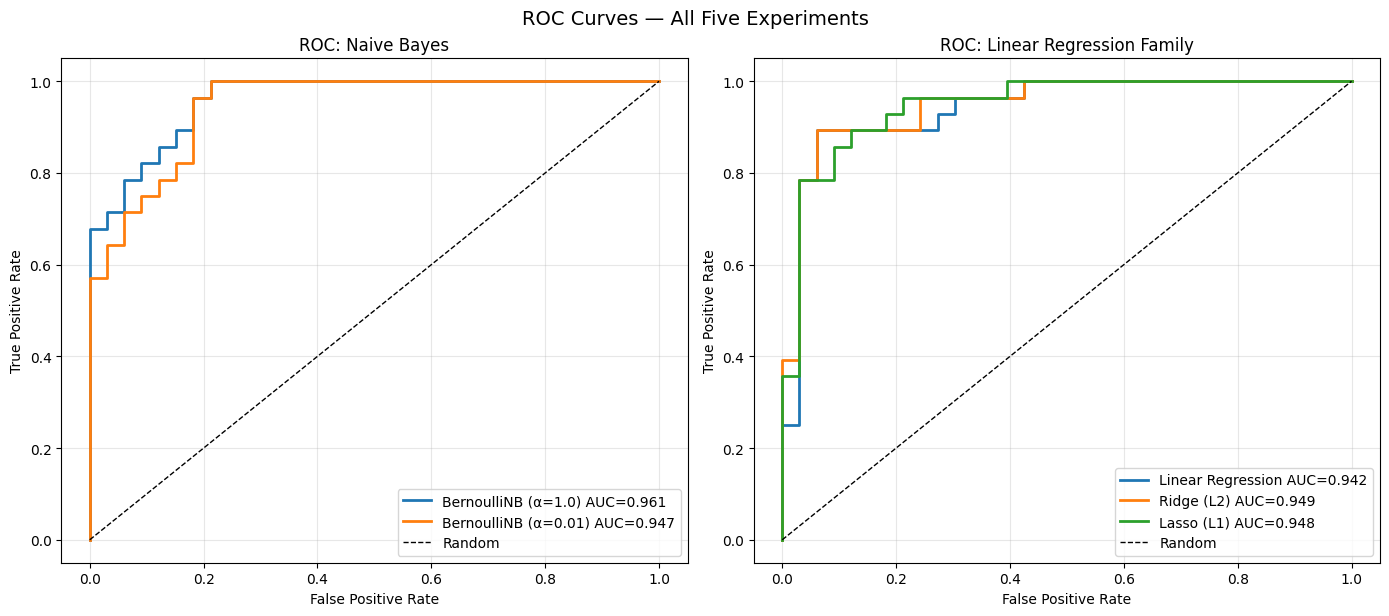

In [48]:
# --- ROC Curves: all five experiments (grouped to avoid clutter) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Naive Bayes (2 models)
ax = axes[0]
for alpha in alphas:
    y_proba = nb_models[alpha].predict_proba(X_test_binary)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"BernoulliNB (α={alpha}) AUC={auc:.3f}", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: Naive Bayes")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

# Right: Linear Regression (3 models)
ax = axes[1]
for name, model in [("Linear Regression", lr), ("Ridge (L2)", ridge), ("Lasso (L1)", lasso)]:
    y_score = np.clip(model.predict(X_test_scaled), 0, 1)
    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)
    ax.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}", lw=2)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC: Linear Regression Family")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.suptitle("ROC Curves — All Five Experiments", y=1.02, fontsize=14)
plt.show()

In [49]:
# --- classification_report for all five models ---
models_reports = [(f"BernoulliNB (α={a})", nb_models[a].predict(X_test_binary)) for a in alphas]
models_reports += [("Linear Regression", y_pred_lr), ("Ridge (L2)", y_pred_ridge), ("Lasso (L1)", y_pred_lasso)]

target_names = ["No disease (0)", "Disease (1)"]
for name, y_pred in models_reports:
    print(f"=== {name} ===\n{classification_report(y_test, y_pred, target_names=target_names, zero_division=0)}\n")

=== BernoulliNB (α=1.0) ===
                precision    recall  f1-score   support

No disease (0)       0.93      0.82      0.87        33
   Disease (1)       0.81      0.93      0.87        28

      accuracy                           0.87        61
     macro avg       0.87      0.87      0.87        61
  weighted avg       0.88      0.87      0.87        61


=== BernoulliNB (α=0.01) ===
                precision    recall  f1-score   support

No disease (0)       0.87      0.82      0.84        33
   Disease (1)       0.80      0.86      0.83        28

      accuracy                           0.84        61
     macro avg       0.84      0.84      0.84        61
  weighted avg       0.84      0.84      0.84        61


=== Linear Regression ===
                precision    recall  f1-score   support

No disease (0)       0.91      0.91      0.91        33
   Disease (1)       0.89      0.89      0.89        28

      accuracy                           0.90        61
     macro 

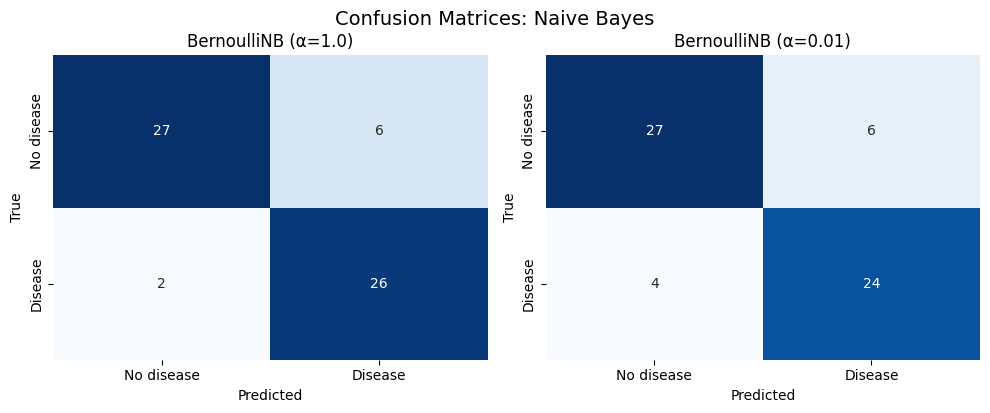

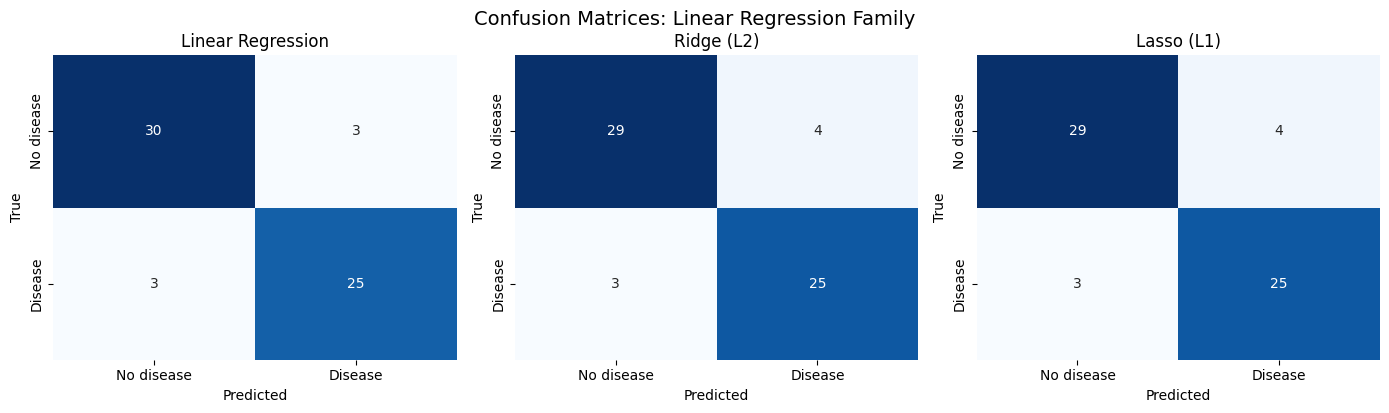

In [50]:
# --- Confusion Matrix Heatmaps (grouped: NB vs Linear Regression) ---
# Group 1: Naive Bayes (2 models)
nb_config = [(f"BernoulliNB (α={a})", nb_models[a].predict(X_test_binary)) for a in alphas]
# Group 2: Linear Regression (3 models)
lr_config = [("Linear Regression", y_pred_lr), ("Ridge (L2)", y_pred_ridge), ("Lasso (L1)", y_pred_lasso)]

fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, y_pred) in zip(axes1.flat, nb_config):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No disease", "Disease"], yticklabels=["No disease", "Disease"])
    ax.set_title(name)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")
plt.tight_layout()
plt.suptitle("Confusion Matrices: Naive Bayes", y=1.02, fontsize=14)
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, y_pred) in zip(axes2.flat, lr_config):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["No disease", "Disease"], yticklabels=["No disease", "Disease"])
    ax.set_title(name)
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.suptitle("Confusion Matrices: Linear Regression Family", y=1.02, fontsize=14)
plt.show()

### Overall Comparison Across Five Experiments

**Why Ridge (L2) and Lasso (L1) have identical performance**

Despite different implementations (L2 penalizes squared coefficients; L1 penalizes absolute values and can zero out features), Ridge (α=1.0) and Lasso (α=0.01) yield exactly the same accuracy, precision, recall, F1, and ROC-AUC on this test set. Possible reasons:

1. **Same discrete predictions after thresholding:** Classification uses `(pred >= 0.5).astype(int)`. Even if raw outputs differ slightly, both models may fall on the same side of 0.5 for every test point, producing identical binary predictions.
2. **Dataset size and feature structure:** With 242 training samples and ~20–30 features (13 original + one-hot + constructed), the solution space can be such that both penalties lead to similar decision boundaries. Lasso’s small α=0.01 applies minimal shrinkage, so it behaves closer to unregularized regression.
3. **Medical data characteristics:** Heart disease predictors (e.g., cholesterol, blood pressure, age) are often correlated. L2 spreads weight across correlated features; L1 may zero out some but retain others. On this dataset, both may converge to equivalent classification decisions.

---

**Why Linear Regression (no regularization) outperforms the others**

OLS achieves the highest accuracy among the five experiments. Possible reasons:

1. **Moderate feature count, limited overfitting:** With 242 samples and ~20–30 features, the model is not severely overparameterized. When the underlying relationship is roughly linear and features are informative, OLS can fit well without needing regularization.
2. **Regularization bias:** Ridge and Lasso shrink coefficients toward zero. If the true coefficients are non-trivial, this shrinkage can reduce fit. For this dataset, the unregularized solution may generalize better than the regularized ones.
3. **Informative medical features:** UCI heart disease variables (age, sex, chest pain type, cholesterol, blood pressure, etc.) have known clinical links to disease. OLS can use all of them; L1/L2 may dampen useful signal.
4. **Small test set variance:** With 61 test samples, observed metric differences can be noisy. If OLS consistently leads, it suggests the unregularized model is well-suited to this data.

---

**Relation to dataset characteristics**

- **Sample size:** 303 samples, 242 train / 61 test — relatively small, typical for medical datasets where data collection is costly.
- **Features:** 13 original variables plus one-hot encoding and constructed ratios (e.g., chol_bp_ratio). Medical datasets often have moderate dimensionality and domain-driven features.
- **Class balance:** Stratified split preserves class distribution; no severe class imbalance.
- **Implications:** In such settings, simpler models (e.g., OLS) can sometimes outperform regularized or probabilistic models when the data are well-structured and the linear decision boundary is appropriate.